In [1]:
# Resource Monitor

import psutil
import os

# Get the current process ID of the IPython kernel
pid = os.getpid()
# Get the process associated with the IPython kernel
process = psutil.Process(pid)

def RAM_USAGE():
    # Get the memory usage of the IPython kernel in MB
    ram_usage_MB = process.memory_info().rss / (1024 * 1024)
    ram_usage_GB = process.memory_info().rss / (1024 * 1024 * 1024)

    # Get the total system memory
    total_memory_MB = psutil.virtual_memory().total / (1024 * 1024)
    total_memory_GB = psutil.virtual_memory().total / (1024 * 1024 * 1024)

    # Get RAM usage percentage
    ram_usage_percent = process.memory_percent()

    # Get the CPU usage percentage of the IPython kernel
    cpu_usage = psutil.cpu_percent()

    print(f"RAM Usage MB: {ram_usage_MB:.2f}/" + f"{total_memory_MB:.2f} MB")
    print(f"RAM Usage GB: {ram_usage_GB:.2f}/"+ f"{total_memory_GB:.2f} GB")
    print(f"RAM Usage percentage: {ram_usage_percent:.2f}%")
    print(f"CPU Usage: {cpu_usage}%")

In [2]:
from Config.Config import ROOT_DATA_PATH
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import pickle
import warnings
import math

# Suppress the warning
warnings.filterwarnings("ignore", category=FutureWarning)

### Get Instrument Metadata

- Include names, codes, industry (optional), status, exchange, etc

In [3]:
begin_date = "20180101"
all_stocks = pd.read_csv(ROOT_DATA_PATH + 'all_stocks.csv', parse_dates=['list_date'])
all_stocks = all_stocks[["ts_code", "name", "industry", "list_status", "list_date", "exchange"]]
all_stocks["list_date"] = pd.to_datetime(all_stocks["list_date"])

# Remove stocks before begin date.
all_stocks = all_stocks[all_stocks["list_date"] <= pd.to_datetime(begin_date)]
all_stocks = all_stocks[all_stocks["list_status"] == "L"]  # Remove unlisted stocks.
all_stocks = all_stocks[all_stocks["exchange"] != "BSE"]
# all_stocks = all_stocks[~all_stocks["name"].str.endswith("(IPO终止)")]
all_stocks = all_stocks[~all_stocks["name"].str.startswith("ST")]  # Remove ST
all_stocks = all_stocks[~all_stocks["name"].str.startswith("*ST")]  # Remove *ST
all_stocks.reset_index(drop=True, inplace=True)

# Remove '000792.SZ' and '000670.SZ' as they have missing values.
# mask = all_stocks['ts_code'].isin(['000792.SZ', '000670.SZ'])
# new_df = all_stocks[mask]
# removing the filtered rows from the original dataframe
# all_stocks = all_stocks[~mask]

stocks_code = list(all_stocks["ts_code"])
with open(ROOT_DATA_PATH + 'stocks_code.pkl', 'wb') as file:
    pickle.dump(stocks_code, file)

In [4]:
all_stocks

,ts_code,name,industry,list_status,list_date,exchange
0,000001.SZ,平安银行,银行,L,1991-04-03,SZSE
1,000002.SZ,万科A,全国地产,L,1991-01-29,SZSE
2,000004.SZ,国华网安,软件服务,L,1991-01-14,SZSE
3,000006.SZ,深振业A,区域地产,L,1992-04-27,SZSE
4,000008.SZ,神州高铁,运输设备,L,1992-05-07,SZSE
...,...,...,...,...,...,...
3148,603991.SH,至正股份,塑料,L,2017-03-08,SSE
3149,603993.SH,洛阳钼业,小金属,L,2012-10-09,SSE
3150,603997.SH,继峰股份,汽车配件,L,2015-03-02,SSE
3151,603998.SH,方盛制药,中成药,L,2014-12-05,SSE


In [5]:
stocks_code

['000001.SZ',
 '000002.SZ',
 '000004.SZ',
 '000006.SZ',
 '000008.SZ',
 '000009.SZ',
 '000010.SZ',
 '000011.SZ',
 '000012.SZ',
 '000014.SZ',
 '000016.SZ',
 '000017.SZ',
 '000019.SZ',
 '000020.SZ',
 '000021.SZ',
 '000025.SZ',
 '000026.SZ',
 '000027.SZ',
 '000028.SZ',
 '000029.SZ',
 '000030.SZ',
 '000031.SZ',
 '000032.SZ',
 '000034.SZ',
 '000035.SZ',
 '000036.SZ',
 '000037.SZ',
 '000039.SZ',
 '000040.SZ',
 '000042.SZ',
 '000045.SZ',
 '000048.SZ',
 '000049.SZ',
 '000050.SZ',
 '000055.SZ',
 '000056.SZ',
 '000058.SZ',
 '000059.SZ',
 '000060.SZ',
 '000061.SZ',
 '000062.SZ',
 '000063.SZ',
 '000065.SZ',
 '000066.SZ',
 '000068.SZ',
 '000069.SZ',
 '000070.SZ',
 '000078.SZ',
 '000088.SZ',
 '000089.SZ',
 '000090.SZ',
 '000096.SZ',
 '000099.SZ',
 '000100.SZ',
 '000151.SZ',
 '000153.SZ',
 '000155.SZ',
 '000156.SZ',
 '000157.SZ',
 '000158.SZ',
 '000159.SZ',
 '000166.SZ',
 '000301.SZ',
 '000333.SZ',
 '000338.SZ',
 '000400.SZ',
 '000401.SZ',
 '000402.SZ',
 '000403.SZ',
 '000404.SZ',
 '000407.SZ',
 '0004

### Trade Date

- If use machine learning, it is necessary to split trade date to train date, validate date and test date.
- Date can be hourly, daily, weekly, monthly, yearly, etc
- Usually use market data to obtain trade date

In [6]:
price_df = pd.read_csv(ROOT_DATA_PATH + 'price.csv', parse_dates=['trade_date'])

In [7]:
price_df.head()

,trade_date,ts_code,OPEN,HIGH,LOW,CLOSE,VOLUME
0,2018-01-02,000001.SZ,13.35,13.93,13.32,13.70,2081590.0
1,2018-01-02,600359.SH,6.84,6.86,6.73,6.79,29309.1
2,2018-01-02,601188.SH,4.11,4.15,4.10,4.14,20111.4
3,2018-01-02,002135.SZ,7.19,7.29,7.17,7.28,42600.7
4,2018-01-02,300554.SZ,60.00,62.63,59.59,61.74,9074.0


In [8]:
# Get trade dates list (like ["2018-01-02", "2018-01-03", ...])
trade_dates_df = price_df[["trade_date"]].drop_duplicates().sort_index(ascending=True).reset_index(drop=True)
trade_dates = list(trade_dates_df["trade_date"].dt.strftime('%Y%m%d'))
trade_dates

['20180102',
 '20180103',
 '20180104',
 '20180105',
 '20180108',
 '20180109',
 '20180110',
 '20180111',
 '20180112',
 '20180115',
 '20180116',
 '20180117',
 '20180118',
 '20180119',
 '20180122',
 '20180123',
 '20180124',
 '20180125',
 '20180126',
 '20180129',
 '20180130',
 '20180131',
 '20180201',
 '20180202',
 '20180205',
 '20180206',
 '20180207',
 '20180208',
 '20180209',
 '20180212',
 '20180213',
 '20180214',
 '20180222',
 '20180223',
 '20180226',
 '20180227',
 '20180228',
 '20180301',
 '20180302',
 '20180305',
 '20180306',
 '20180307',
 '20180308',
 '20180309',
 '20180312',
 '20180313',
 '20180314',
 '20180315',
 '20180316',
 '20180319',
 '20180320',
 '20180321',
 '20180322',
 '20180323',
 '20180326',
 '20180327',
 '20180328',
 '20180329',
 '20180330',
 '20180402',
 '20180403',
 '20180404',
 '20180409',
 '20180410',
 '20180411',
 '20180412',
 '20180413',
 '20180416',
 '20180417',
 '20180418',
 '20180419',
 '20180420',
 '20180423',
 '20180424',
 '20180425',
 '20180426',
 '20180427',

### Get Price and Return (for instruments and benchmark)

- Original price data

| trade_date   | ts_code   |    OPEN |    HIGH |     LOW |   CLOSE |      VOLUME |
|:-------------|:----------|--------:|--------:|--------:|--------:|------------:|
| 2018-01-02   | 000300.SH | 4045.21 | 4087.78 | 4045.21 | 4087.4  | 1.46935e+08 |
| 2018-01-02   | 000905.SH | 6263.15 | 6332.61 | 6258.16 | 6332.23 | 7.30322e+07 |
| 2018-01-02   | 000852.SH | 7027.63 | 7092.22 | 7022.23 | 7092.09 | 7.7191e+07  |
| 2018-01-03   | 000300.SH | 4091.46 | 4140.05 | 4088.73 | 4111.39 | 1.51852e+08 |
| 2018-01-03   | 000905.SH | 6331.72 | 6391.98 | 6324.26 | 6388.25 | 8.39367e+07 |

- Note the original price data is 3-d data frame (date × market data × instrument). We should convert it to different 2-d data frame (date × instrument) for each market data. So does return data.

- ❗ **Return calculation**

> the first day's Return: $\frac{CLOSE_{today} - OPEN_{today}}{OPEN_{today}}$
> 
> the rest of the days' Return: $\frac{CLOSE_{today} - CLOSE_{yesterday}}{CLOSE_{yesterday}}$

In [9]:
# Get CLOSE data
close_df = price_df.pivot(index='trade_date', columns='ts_code', values='CLOSE')
open_df = price_df.pivot(index='trade_date', columns='ts_code', values='OPEN')

In [10]:
# Get benchmark data
benchmark_df = pd.read_csv(ROOT_DATA_PATH + 'benchmark.csv', parse_dates=['trade_date'])
benchmark_close_df = benchmark_df.pivot(index='trade_date', columns='ts_code', values='CLOSE')
benchmark_open_df = benchmark_df.pivot(index='trade_date', columns='ts_code', values='OPEN')

In [11]:
# Ensure the close_df, open_df have the same stock columns in `stocks_code`
common_stocks = set(close_df.columns) & set(open_df.columns) & set(stocks_code)
common_stocks = sorted(list(common_stocks))
set(common_stocks) - set(stocks_code) # should be empty set

set()

In [12]:
# Also, because we will calculate returns, be sure the order of columns are the same
close_df = close_df[common_stocks]
open_df = open_df[common_stocks]

In [13]:
# Get Return data 
# The first day's return is calculated by (close - open) / open)
# The other days' returns are calculated by close-to-close pct change.
price_return_df = close_df.pct_change()
first_day_return = (close_df.iloc[0] - open_df.iloc[0]) / open_df.iloc[0]
price_return_df.iloc[0] = first_day_return
price_return_df

ts_code,000001.SZ,000002.SZ,000004.SZ,000006.SZ,000008.SZ,000009.SZ,000010.SZ,000011.SZ,000012.SZ,000014.SZ,...,603986.SH,603987.SH,603988.SH,603989.SH,603990.SH,603991.SH,603993.SH,603997.SH,603998.SH,603999.SH
trade_date,,,,,,,,,,,,,,,,,,,,,
2018-01-02,0.026217,0.035294,0.002243,0.000000,0.002286,0.006878,0.018587,0.013049,0.033573,0.012987,...,0.000000,-0.000821,-0.009292,-0.007275,0.016494,-0.002837,0.005797,0.016143,-0.010667,0.013004
2018-01-03,-0.027007,-0.007064,0.065354,0.000000,-0.002281,0.013661,0.009124,0.003513,0.031323,0.004579,...,0.000000,0.000822,0.023748,0.015703,0.003300,0.000000,0.015850,0.003530,0.006289,0.002567
2018-01-04,-0.006002,0.024436,-0.023529,0.000000,-0.008000,0.029650,-0.009042,0.000583,-0.015748,0.008204,...,0.000000,0.009031,-0.001559,0.001288,0.001645,0.002489,0.025532,-0.006157,0.044643,-0.006402
2018-01-05,0.003774,0.049517,-0.002582,0.000000,-0.014977,-0.011780,0.029197,0.046647,-0.003429,0.100362,...,0.000000,-0.011391,-0.012105,-0.008492,0.015873,-0.002838,-0.009682,-0.007080,-0.012821,0.006443
2018-01-08,-0.025564,0.035386,-0.014668,0.000000,-0.009357,-0.003974,0.099291,-0.003900,0.020642,0.100247,...,0.000000,-0.013169,-0.020553,0.008824,0.046067,-0.007471,0.019553,-0.016043,0.009524,-0.007682
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-05-27,0.017683,-0.013348,-0.008174,-0.012407,0.000000,0.001992,-0.005376,-0.013841,-0.003436,-0.004625,...,0.036641,0.006859,-0.001121,0.000699,-0.017442,0.017494,0.044010,-0.001759,0.005025,0.009294
2024-05-28,-0.009557,-0.039459,-0.021978,-0.027638,-0.018349,-0.018887,-0.027027,-0.024561,-0.017241,-0.029740,...,0.002577,-0.019074,0.033670,-0.015363,-0.011834,-0.023572,0.000000,-0.015859,-0.012500,-0.022099
2024-05-29,-0.012281,0.007042,0.000000,0.012920,-0.004673,0.005066,0.011111,0.007194,0.003509,0.018199,...,-0.015302,0.008333,-0.020630,0.000000,0.007984,0.004260,0.025761,0.005372,-0.007595,-0.005650


In [14]:
# Get benchmark return data
benchmark_return_df = benchmark_close_df.pct_change()
first_day_benchmark_return = (benchmark_close_df.iloc[0] - benchmark_open_df.iloc[0]) / benchmark_open_df.iloc[0]
benchmark_return_df.iloc[0] = first_day_benchmark_return

### Data preprocession (Optional)

- Null value handling
- Remove unexpected instruments
- Data transformation (Only for Machine Learning)

### Make Label (Only for Machine Learning)

### Strategy

- Use strategy to genetate trading signal (i.e. factor value)
- Use trading signal to genetate position ratio for each instrument (weight value)
- Neutralization (optional)
- Use return data and weight value to generate PnL data

`Get Signals`

In [18]:
"""
Use simple Double Moving Average Strategy to select instruments.

Strategy Logic:
1. Calculate short-term and long-term moving averages.
2. Generate buy/sell signals based on the crossover of these moving averages.

If the short-term moving average crosses above the long-term moving average, it generates a buy signal.
Conversely, if the short-term moving average crosses below the long-term moving average, it generates a sell signal.

Note that the close_df contains multiple stocks' close prices, so we calculate the mean across all stocks for the moving averages.

The output signals DataFrame should have the same dimensions as close_df.

(Important) If there is a buy signal, the value is 1.0; if there is a sell signal, the value is -1.0; otherwise, it is 0.0.
(The signal is generated after the settlement time of the trading day. 
For example, if a buy signal is generated on day T, the actual buy action will be executed at the opening of day T+1.)

The frequency of signals generation is daily.

Note that if a stock has already been bought, the subsequent buy signals will be ignored until a sell signal is generated.
Conversely, if a stock has already been sold, the subsequent sell signals will be ignored until a buy signal is generated.
"""
# Based on the above logic, implement the Double Moving Average Strategy to generate signals.
# The output signals DataFrame should have the same dimensions as close_df.
short_window = 20
long_window = 50
signals = pd.DataFrame(index=close_df.index, columns=close_df.columns)
signals = signals.ffill()
# Calculate the short-term and long-term moving averages (do not use double for loop)
rolling_mean_short = close_df.rolling(window=short_window, min_periods=1).mean()
"""
Exlpanation:
- close_df.rolling(window=short_window, min_periods=1) creates a rolling window object for the close_df DataFrame with a specified 
window size of short_window (20 in this case). The min_periods=1 parameter ensures that the rolling mean is calculated even if there 
are fewer than 20 data points available at the beginning of the series.
- .mean() computes the mean of the values within each rolling window, resulting in a new DataFrame where each value represents the 
average of the previous 20 (or fewer, at the start) closing prices for each stock.
"""
rolling_mean_long = close_df.rolling(window=long_window, min_periods=1).mean()
# Generate signals
signals[(rolling_mean_short > rolling_mean_long)] = 1.0
signals[(rolling_mean_short < rolling_mean_long)] = -1.0
# signals[(rolling_mean_short > rolling_mean_long) & (signals.shift(1) != 1.0)] = 1.0
# signals[(rolling_mean_short < rolling_mean_long) & (signals.shift(1) != -1.0)] = -1.0
signals.fillna(0.0, inplace=True)
signals

ts_code,000001.SZ,000002.SZ,000004.SZ,000006.SZ,000008.SZ,000009.SZ,000010.SZ,000011.SZ,000012.SZ,000014.SZ,...,603986.SH,603987.SH,603988.SH,603989.SH,603990.SH,603991.SH,603993.SH,603997.SH,603998.SH,603999.SH
trade_date,,,,,,,,,,,,,,,,,,,,,
2018-01-02,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2018-01-03,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2018-01-04,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2018-01-05,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2018-01-08,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-05-27,1.0,-1.0,-1.0,1.0,-1.0,-1.0,-1.0,1.0,1.0,-1.0,...,1.0,1.0,-1.0,-1.0,-1.0,-1.0,1.0,-1.0,1.0,-1.0
2024-05-28,1.0,-1.0,-1.0,1.0,-1.0,-1.0,-1.0,1.0,1.0,-1.0,...,1.0,1.0,-1.0,-1.0,-1.0,-1.0,1.0,-1.0,1.0,-1.0
2024-05-29,1.0,1.0,-1.0,1.0,-1.0,-1.0,-1.0,1.0,1.0,-1.0,...,1.0,1.0,-1.0,-1.0,-1.0,-1.0,1.0,-1.0,1.0,-1.0


`Get Positions and Fee`

In [20]:
"""
We change our position daily. Now, we get position dataframe (0 or 1) based on the signals.
(Explanation: position = 1 means we hold the stock, position = 0 means we do not hold the stock)
(If the instrument can be shorted, position = -1 means we short the stock)
(Note that we suppose the instruments cannot be shorted in this example.)

In order to avoid future data leakage, we will shift the signals by one day when calculating weights.
(i.e. the weight on day t is based on the signal generated on day t-1)

In the position changing day, we will take the full position according to the signal.
There are 9 possible situations:
Previous signal = 0.0, Current signal = 1.0  => position = 1.0 (buy)
Previous signal = 0.0, Current signal = -1.0 => position = 0.0 (do nothing, cannot short)
Previous signal = 0.0, Current signal = 0.0  => position = 0.0 (do nothing)
Previous signal = 1.0, Current signal = 1.0  => position = 1.0 (hold)
Previous signal = 1.0, Current signal = -1.0 => position = 0.0 (sell)
Previous signal = 1.0, Current signal = 0.0  => position = 1.0 (hold)
Previous signal = -1.0, Current signal = 1.0 => position = 1.0 (buy)
Previous signal = -1.0, Current signal = -1.0 => position = 0.0 (do nothing, cannot short)
Previous signal = -1.0, Current signal = 0.0 => position = 0.0 (do nothing, cannot short)

More generally, if we change the position weekly (or other frequency), we can follow the same logic.
First, add a new column 'week' to the signals DataFrame, which indicates the week number of each date.
Then, we keep only the signals on each position changing day (e.g., Monday) (After the signals are shifted).
Then, we can follow the same logic as above to calculate the positions.
Finally, we reindex the positions DataFrame to match the original signals DataFrame, forward filling the positions for the days in between.
"""
signals_shifted = signals.shift(1).fillna(0.0)
# We change our position daily. Now, we get position dataframe (0 or 1) based on the signals.

positions = signals_shifted.copy()
positions[(signals_shifted == 0.0) & (signals == 1.0)] = 1.0  # buy
positions[(signals_shifted == 0.0) & (signals == -1.0)] = 0.0  # do nothing, cannot short
positions[(signals_shifted == 0.0) & (signals == 0.0)] = 0.0  # do nothing
positions[(signals_shifted == 1.0) & (signals == 1.0)] = 1.0  # hold
positions[(signals_shifted == 1.0) & (signals == -1.0)] = 0.0  # sell
positions[(signals_shifted == 1.0) & (signals == 0.0)] = 1.0  # hold
positions[(signals_shifted == -1.0) & (signals == 1.0)] = 1.0  # buy
positions[(signals_shifted == -1.0) & (signals == -1.0)] = 0.0  # do nothing, cannot short
positions[(signals_shifted == -1.0) & (signals == 0.0)] = 0.0  # do nothing, cannot short

"""
Also, we can get fee DataFrame based on the position changes.
If the position changes (from 0 to 1, or from 1 to 0), we will incur a transaction fee.
Suppose the transaction fee is 0.1% (0.001) for both buy and sell.
"""
fee_buy_rate = 0.001
fee_sell_rate = 0.001
fee = pd.DataFrame(0.0, index=positions.index, columns=positions.columns)
# Identify where positions change
position_buy_changes = positions.diff() == 1.0
position_sell_changes = positions.diff() == -1.0

# Apply fees for buys and sells
fee[position_buy_changes] = fee_buy_rate
fee[position_sell_changes] = fee_sell_rate

In [21]:
positions

ts_code,000001.SZ,000002.SZ,000004.SZ,000006.SZ,000008.SZ,000009.SZ,000010.SZ,000011.SZ,000012.SZ,000014.SZ,...,603986.SH,603987.SH,603988.SH,603989.SH,603990.SH,603991.SH,603993.SH,603997.SH,603998.SH,603999.SH
trade_date,,,,,,,,,,,,,,,,,,,,,
2018-01-02,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2018-01-03,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2018-01-04,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2018-01-05,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2018-01-08,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-05-27,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,...,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
2024-05-28,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,...,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
2024-05-29,1.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,...,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0


In [22]:
fee

ts_code,000001.SZ,000002.SZ,000004.SZ,000006.SZ,000008.SZ,000009.SZ,000010.SZ,000011.SZ,000012.SZ,000014.SZ,...,603986.SH,603987.SH,603988.SH,603989.SH,603990.SH,603991.SH,603993.SH,603997.SH,603998.SH,603999.SH
trade_date,,,,,,,,,,,,,,,,,,,,,
2018-01-02,0.0,0.000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.000,0.0,0.0,0.0,0.0,0.0
2018-01-03,0.0,0.000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.000,0.0,0.0,0.0,0.0,0.0
2018-01-04,0.0,0.000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.000,0.0,0.0,0.0,0.0,0.0
2018-01-05,0.0,0.000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.000,0.0,0.0,0.0,0.0,0.0
2018-01-08,0.0,0.000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.000,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-05-27,0.0,0.000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.000,0.0,0.0,0.0,0.0,0.0
2024-05-28,0.0,0.000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.000,0.0,0.0,0.0,0.0,0.0
2024-05-29,0.0,0.001,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.000,0.0,0.0,0.0,0.0,0.0


`Get Weights`

In [23]:
"""
After getting the positions DataFrame, we can calculate the weights DataFrame.
The weights are calculated based on the positions and the number of stocks held.

In realistic, we think about the following:
1. At the position changing day, the long position instruments may have overlapping elements with the previous long position instruments.
   In this case, we only need to buy the new long position instruments, and sell the the instruments that are no longer in the long position.
   Also, we need to rebalance the weights of the held instruments.
   (In this example, we assume we always take full position according to the signals, so the weights are equal weighted among the held instruments.)
"""
num_stocks_held = positions.sum(axis=1)
weights = positions.div(num_stocks_held, axis=0).fillna(0.0)
weights

ts_code,000001.SZ,000002.SZ,000004.SZ,000006.SZ,000008.SZ,000009.SZ,000010.SZ,000011.SZ,000012.SZ,000014.SZ,...,603986.SH,603987.SH,603988.SH,603989.SH,603990.SH,603991.SH,603993.SH,603997.SH,603998.SH,603999.SH
trade_date,,,,,,,,,,,,,,,,,,,,,
2018-01-02,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.0,...,0.000000,0.000000,0.0,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0
2018-01-03,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.0,...,0.000000,0.000000,0.0,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0
2018-01-04,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.0,...,0.000000,0.000000,0.0,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0
2018-01-05,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.0,...,0.000000,0.000000,0.0,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0
2018-01-08,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.0,...,0.000000,0.000000,0.0,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-05-27,0.000639,0.000000,0.0,0.000639,0.0,0.0,0.0,0.000639,0.000639,0.0,...,0.000639,0.000639,0.0,0.0,0.000000,0.0,0.000639,0.0,0.000639,0.0
2024-05-28,0.000623,0.000000,0.0,0.000623,0.0,0.0,0.0,0.000623,0.000623,0.0,...,0.000623,0.000623,0.0,0.0,0.000000,0.0,0.000623,0.0,0.000623,0.0
2024-05-29,0.000613,0.000613,0.0,0.000613,0.0,0.0,0.0,0.000613,0.000613,0.0,...,0.000613,0.000613,0.0,0.0,0.000000,0.0,0.000613,0.0,0.000613,0.0


In [24]:
positions.sum(axis=1)

trade_date
2018-01-02       0.0
2018-01-03       0.0
2018-01-04       0.0
2018-01-05       0.0
2018-01-08       0.0
               ...  
2024-05-27    1565.0
2024-05-28    1605.0
2024-05-29    1632.0
2024-05-30    1604.0
2024-05-31    1593.0
Length: 1555, dtype: float64

### Backtesting

- Layer analysis
> Note: Layer analysis is used to analyze the performance of different groups of instruments based on their factor values. For example, instruments can be divided into quintiles based on their signal values, and the performance of each quintile can be analyzed separately. However, this step may not be necessary for all strategies, especially if the strategy does not involve ranking or grouping instruments based on factor values. For example, in a simple moving average crossover strategy, the focus is on generating buy and sell signals based on moving averages rather than ranking instruments. In such cases, layer analysis may not provide additional insights and can be skipped.
- Simple backtesting

In [25]:
# Get benchmark return data
HS_300 = benchmark_return_df["000300.SH"]
CS_500 = benchmark_return_df["000905.SH"]
CS_1000 = benchmark_return_df["000852.SH"]

"""
We now have:
1. positions DataFrame: indicates whether we hold each stock on each day (1.0 for hold, 0.0 for not hold).
2. fee DataFrame: indicates the transaction fee incurred on each stock on each day (0.0 if no transaction, otherwise the fee rate).
3. weights DataFrame: indicates the weight of each stock in the portfolio on each day (equal weighted among held stocks).
These DataFrames can be used for backtesting the trading strategy.

Now we can calculate the daily portfolio returns based on the weights and price returns.
The daily portfolio return is calculated as the sum of the product of weights and price returns for all stocks.
"""
portfolio_return_df = (weights * (price_return_df - fee)).sum(axis=1)
portfolio_return_df

trade_date
2018-01-02    0.000000
2018-01-03    0.000000
2018-01-04    0.000000
2018-01-05    0.000000
2018-01-08    0.000000
                ...   
2024-05-27    0.009289
2024-05-28   -0.009384
2024-05-29    0.000766
2024-05-30   -0.010313
2024-05-31    0.001769
Length: 1555, dtype: float64

`Layer Analysis`

`Simple Analysis`

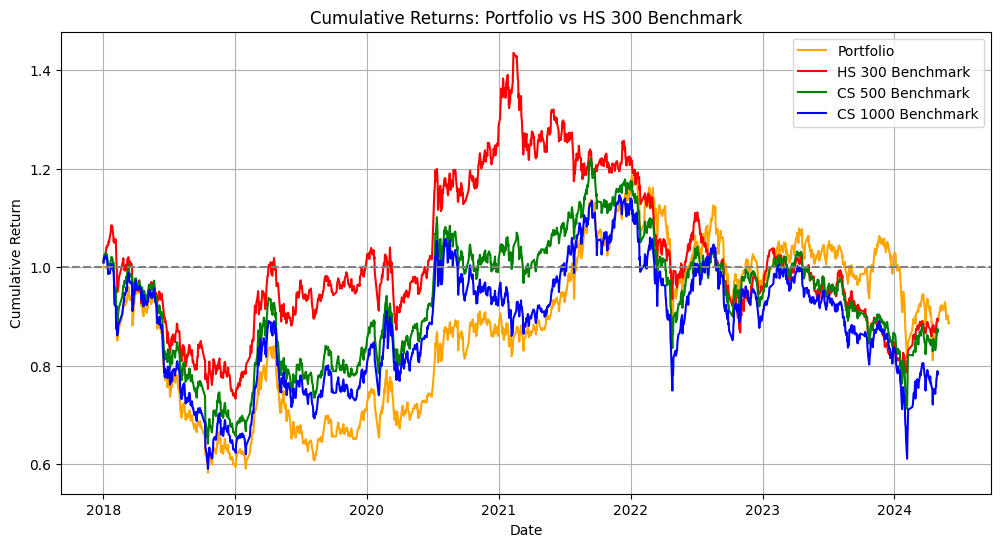

In [26]:
# Then, plot the cumulative returns of the portfolio and benchmark for comparison.
cumulative_portfolio_return = (1 + portfolio_return_df).cumprod()
cumulative_HS300_return = (1 + HS_300).cumprod()
cumulative_CS_500_return = (1 + CS_500).cumprod()
cumulative_CS_1000_return = (1 + CS_1000).cumprod()
plt.figure(figsize=(12, 6))
plt.plot(cumulative_portfolio_return.index, cumulative_portfolio_return, label='Portfolio', color="orange")
plt.plot(cumulative_HS300_return.index, cumulative_HS300_return, label='HS 300 Benchmark', color="r")
plt.plot(cumulative_CS_500_return.index, cumulative_CS_500_return, label='CS 500 Benchmark', color="g")
plt.plot(cumulative_CS_1000_return.index, cumulative_CS_1000_return, label='CS 1000 Benchmark', color="b")
plt.xlabel('Date')
plt.ylabel('Cumulative Return')
plt.title('Cumulative Returns: Portfolio vs HS 300 Benchmark')
plt.axhline(y=1, color="grey", linestyle="--")
plt.legend()
plt.grid(True)
plt.show()

### Indexes

- RankIC (IC)
- ICIR
- IC winning rate
- Winning rate
- ROI
- APY (Annual Percentage Yield)
- Sharpe
- Alpha
- Beta
- Volatility
- Max drawdown
- Turnover
- Fitness
- Margin

d:\anaconda3\Lib\site-packages\pandas\core\nanops.py:1632: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  return spearmanr(a, b)[0]


IC mean: -0.013032958436622891
ICIR: -0.10528707796556747


<Axes: >

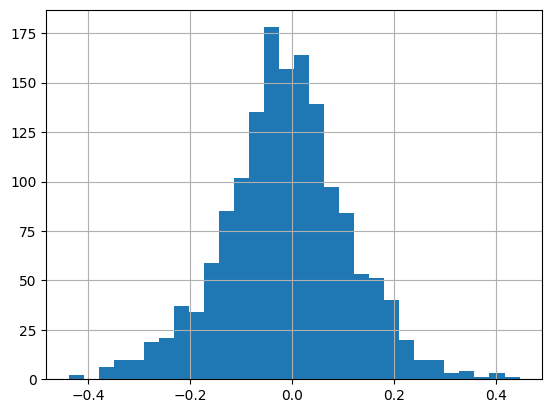

In [27]:
# Get indexes based on the cumulative returns
# IC Series
IC_Series = signals.corrwith(price_return_df, axis=1, method="spearman")
IC_mean = IC_Series.mean()
print(f"IC mean: {IC_mean}")
ICIR = IC_Series.mean() / IC_Series.std()
print(f"ICIR: {ICIR}")
IC_Series.hist(bins=30)

Text(0, 0.5, 'Cumulative Sum')

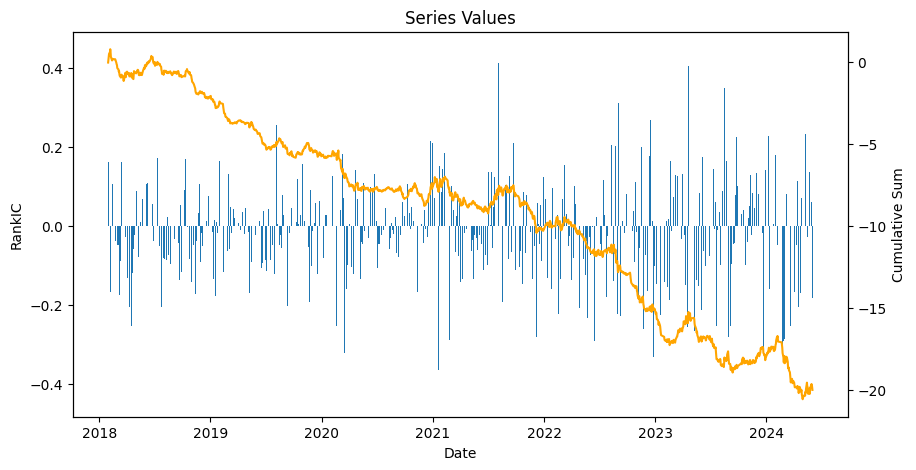

In [31]:
# RankIC
# Create a figure and axis
_, ax = plt.subplots(figsize=(10, 5))
# Plot histogram of values on the left side
ax.bar(IC_Series.index, IC_Series.values)
ax.set_title('Series Values')
ax.set_xlabel('Date')
ax.set_ylabel('RankIC')
# Create a twin Axes sharing the xaxis
ax2 = ax.twinx()
# Plot cumulative line on the right side
ax2.plot(IC_Series.index, IC_Series.cumsum(), color='orange')
ax2.set_ylabel('Cumulative Sum')

In [32]:
# IC winning rate
IC_winning_rate = sum(1 for ic in IC_Series if ic > 0) / len(IC_Series)
print(f"IC winning rate: {IC_winning_rate}")

# t-value
t_value = ICIR / math.sqrt(len(IC_Series))
print(f"IC t-value: {t_value}")

IC winning rate: 0.44887459807073954
IC t-value: -0.0026699914840871797


In [34]:
# ROI
ROI = cumulative_portfolio_return.iloc[-1] - 1
HS_300_ROI = cumulative_HS300_return.iloc[-1] - 1
CS_500_ROI = cumulative_CS_500_return.iloc[-1] - 1
CS_1000_ROI = cumulative_CS_1000_return.iloc[-1] - 1
print(f"ROI: {ROI:.4f}")
print(f"HS 300 ROI: {HS_300_ROI:.4f}")
print(f"CS 500 ROI: {CS_500_ROI:.4f}")
print(f"CS 1000 ROI: {CS_1000_ROI:.4f}")

# APY
APY = (cumulative_portfolio_return.iloc[-1]) ** (252 / len(cumulative_portfolio_return)) - 1
HS_300_APY = (cumulative_HS300_return.iloc[-1]) ** (252 / len(cumulative_HS300_return)) - 1
CS_500_APY = (cumulative_CS_500_return.iloc[-1]) ** (252 / len(cumulative_CS_500_return)) - 1
CS_1000_APY = (cumulative_CS_1000_return.iloc[-1]) ** (252 / len(cumulative_CS_1000_return)) - 1
print(f"APY: {APY:.4f}")
print(f"HS 300 APY: {HS_300_APY:.4f}")
print(f"CS 500 APY: {CS_500_APY:.4f}")
print(f"CS 1000 APY: {CS_1000_APY:.4f}")

ROI: -0.1131
HS 300 ROI: -0.1090
CS 500 ROI: -0.1312
CS 1000 ROI: -0.2177
APY: -0.0193
HS 300 APY: -0.0188
CS 500 APY: -0.0228
CS 1000 APY: -0.0395


In [35]:
HS_300

trade_date
2018-01-02    0.010430
2018-01-03    0.005869
2018-01-04    0.004237
2018-01-05    0.002407
2018-01-08    0.005173
                ...   
2024-04-24    0.004392
2024-04-25    0.002459
2024-04-26    0.015293
2024-04-29    0.011059
2024-04-30   -0.005386
Name: 000300.SH, Length: 1534, dtype: float64

In [36]:
# Sharpe Ratio
"""
Explanation:
The Sharpe Ratio is a measure of risk-adjusted return. It is calculated as the average return of the portfolio minus the risk-free rate, divided by the standard deviation of the portfolio returns.
In this example, we assume the risk-free rate is 0 for simplicity. The formula used here is:
Sharpe Ratio = (Mean Portfolio Return / Standard Deviation of Portfolio Return) * sqrt(252)
"""
sharpe_ratio = (portfolio_return_df.mean() / portfolio_return_df.std()) * math.sqrt(252)
HS_300_sharpe_ratio = (HS_300.mean() / HS_300.std()) * math.sqrt(252)
CS_500_sharpe_ratio = (CS_500.mean() / CS_500.std()) * math.sqrt(252)
CS_1000_sharpe_ratio = (CS_1000.mean() / CS_1000.std()) * math.sqrt(252)
print(f"Sharpe Ratio: {sharpe_ratio:.4f}")
print(f"HS 300 Sharpe Ratio: {HS_300_sharpe_ratio:.4f}")
print(f"CS 500 Sharpe Ratio: {CS_500_sharpe_ratio:.4f}")
print(f"CS 1000 Sharpe Ratio: {CS_1000_sharpe_ratio:.4f}")

Sharpe Ratio: 0.0284
HS 300 Sharpe Ratio: 0.0004
CS 500 Sharpe Ratio: 0.0020
CS 1000 Sharpe Ratio: -0.0470


In [41]:
# Beta = cov(Asset Equity, Benchmark Equity) / Var(Benchmark Equity)
# Alpha = Yield Asset ROI - (Riskless ROI + β * (Yield Benchmark ROI - Riskless ROI))
"""
α > 0 strategy has achieved excess returns relative to the market
α = 0 strategy achieved an appropriate return relative to the market
α < 0 strategy has achieved relatively low returns relative to the market

β < 0 portfolios and benchmarks usually move in the opposite direction, such as short positions
β = 0 There is no correlation between the direction of the portfolio and the benchmark, such as fixed income
0 < β < 1 The portfolio and benchmark move in the same direction, but by a smaller margin than the benchmark
β = 1 Portfolio and benchmark move in the same direction and close to the benchmark
β > 1 portfolios and benchmarks move in the same direction, but more dramatically than benchmarks
"""
Beta = cumulative_portfolio_return.cov(cumulative_HS300_return) / cumulative_HS300_return.var()
Alpha = APY - (0.03 + Beta * (HS_300_APY - 0.03))
print(f"β: {Beta: .2f}")
print(f"α: {Alpha: .2f}")

β:  0.43
α: -0.03


In [ ]:
"""
Volatility is a statistical measure of the dispersion of returns for a given security or market index.
In this example, we calculate the annualized volatility of the portfolio returns using the standard deviation of daily returns.

# Daily Volatility = sqrt(sum((Return - mean(Return)) ** 2))
# Annual Volatility = sqrt(252) * Daily Volatility
"""
Asset_Annual_Volatility = portfolio_return_df.std() * math.sqrt(252)
Benchmark_Annual_Volatility = HS_300.std() * math.sqrt(252)
Asset_Sharpe_Ratio = APY / Asset_Annual_Volatility
Benchmark_Sharpe_Ratio = HS_300_APY / Benchmark_Annual_Volatility
print(f"Asset Annual Volatility: {Asset_Annual_Volatility: .2f}")
print(f"Benchmark Annual Volatility: {Benchmark_Annual_Volatility: .2f}")
print(f"Asset Sharpe Ratio: {Asset_Sharpe_Ratio: .2f}")
print(f"Benchmark Sharpe Ratio: {Benchmark_Sharpe_Ratio: .2f}")

Asset Annual Volatility:  0.23
Benchmark Annual Volatility:  0.19
Asset Sharpe Ratio: -0.08
Benchmark Sharpe Ratio: -0.10


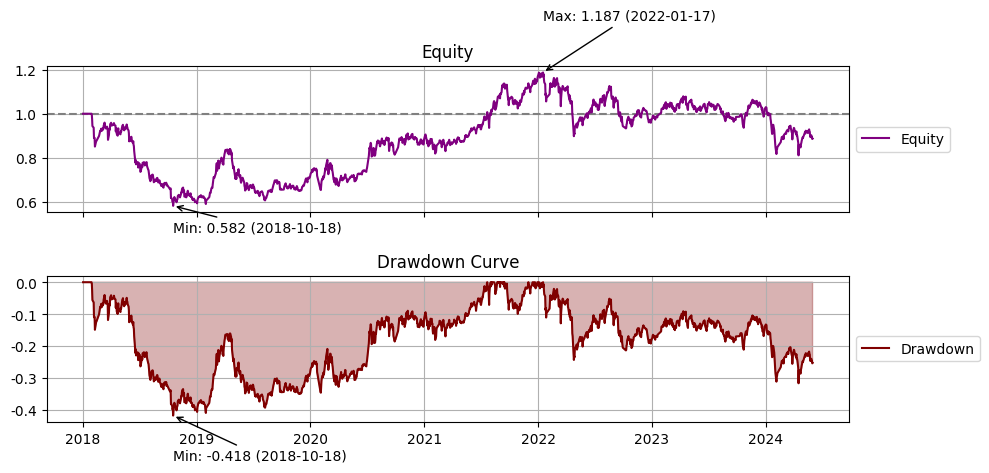

In [40]:
# Calculate drawdown

plt.rcParams["axes.unicode_minus"] = False  # Display negative sign correctly
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 5), sharex=True)

max_equity = max(cumulative_portfolio_return)
max_equity_date = cumulative_portfolio_return.idxmax().date()
min_equity = min(cumulative_portfolio_return)
min_equity_date = cumulative_portfolio_return.idxmin().date()
ax1.axhline(y=1, color="grey", linestyle="--")
ax1.plot(cumulative_portfolio_return, label="Equity", color="#800080")
ax1.set_title(f"Equity")
ax1.legend(bbox_to_anchor=(1, 0.5), loc="center left")
# Annotate max value of equity
ax1.annotate(f'Max: {max_equity:.3f} ({max_equity_date})', xy=(cumulative_portfolio_return.idxmax(), max_equity),
        xytext=(cumulative_portfolio_return.idxmax(), max_equity + max_equity / 5),
        arrowprops=dict(facecolor='black', arrowstyle='->'))
# Annotate min value of equity
ax1.annotate(f'Min: {min_equity:.3f} ({min_equity_date})', xy=(cumulative_portfolio_return.idxmin(), min_equity),
        xytext=(cumulative_portfolio_return.idxmin(), min_equity - min_equity / 5),
        arrowprops=dict(facecolor='black', arrowstyle='->'))


rolling_max = cumulative_portfolio_return.cummax()
drawdown = (cumulative_portfolio_return - rolling_max) / rolling_max
max_drawdown = min(drawdown)
max_drawdown_start = drawdown.idxmin().date()

ax2.plot(drawdown, label="Drawdown", color="maroon")
# Shade the area where drawdown is negative
ax2.fill_between(drawdown.index, 
                drawdown, 
                0, 
                where=drawdown < 0, 
                color='maroon', 
                alpha=0.3)
ax2.set_title("Drawdown Curve")
ax2.legend(bbox_to_anchor=(1, 0.5), loc="center left")
# Annotate min value of ax2
ax2.annotate(f'Min: {max_drawdown:.3f} ({max_drawdown_start})', xy=(drawdown.idxmin(), max_drawdown),
        xytext=(drawdown.idxmin(), max_drawdown + max_drawdown / 3),
        arrowprops=dict(facecolor='black', arrowstyle='->'))

ax1.grid(True)
ax2.grid(True)
plt.tight_layout()
plt.show()

### External Analysis

- Industry analysis
- Correlation analysis (for different factors)

### Mock Trading

- API
- Transaction Fee
- Slippage
- Latency (network quality, code efficiency)
- Cloud Deployment (7 x 24 monitoring)
- Concurrent running

### Real Trading